In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

import os

plt.style.use("ggplot")

os.makedirs("../reports/figures", exist_ok=True)

In [2]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

fund_master = pd.read_csv("../data/processed/fund_master_cleaned.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_cleaned.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_cleaned.csv")

category = pd.read_csv("../data/processed/category_inflows_cleaned.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_cleaned.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_cleaned.csv")

portfolio = pd.read_csv("../data/processed/portfolio_holdings_cleaned.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

Compute Daily Returns

In [4]:
nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)
returns = nav.dropna(
    subset=["daily_return"]
)
returns.to_csv(
    "../data/processed/daily_returns.csv",
    index=False
)

Validate Distribution

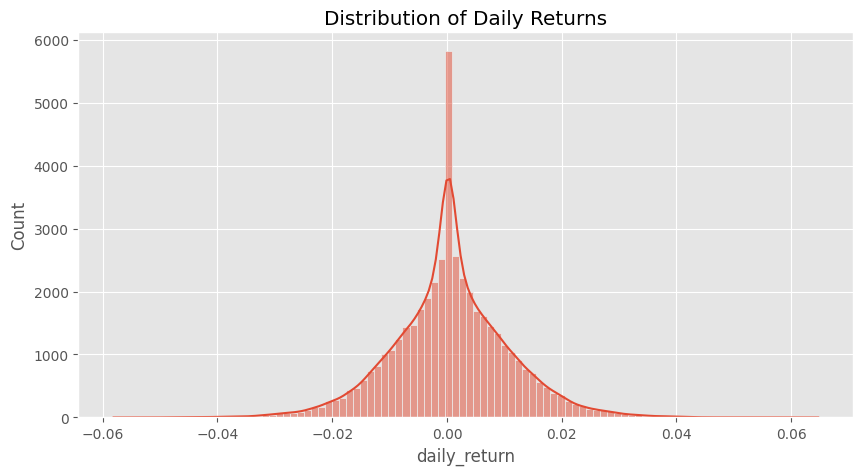

In [5]:
plt.figure(figsize=(10,5))

sns.histplot(
    returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

Daily returns are approximately centered around zero with slight positive skew and a few extreme tails caused by volatile market sessions.

CAGR 

In [6]:
def calculate_cagr(df, years):

    start = df.iloc[0]["nav"]

    end = df.iloc[-1]["nav"]

    return (end/start)**(1/years)-1

results=[]

for code,group in nav.groupby("amfi_code"):

    group=group.sort_values("date")

    cagr1=calculate_cagr(group.tail(252),1)

    cagr3=calculate_cagr(group.tail(252*3),3)

    cagr5=calculate_cagr(group.tail(252*5),5)

    results.append([

        code,

        cagr1,

        cagr3,

        cagr5

    ])

cagr=pd.DataFrame(

results,

columns=[

"amfi_code",

"cagr_1yr",

"cagr_3yr",

"cagr_5yr"

]
)
cagr=cagr.merge(

fund_master[

["amfi_code","scheme_name"]

],

on="amfi_code"

)
cagr.to_csv(

"../data/processed/cagr_summary.csv",

index=False

)

Comparison Table

In [7]:
cagr.sort_values(

"cagr_3yr",

ascending=False

).head(10)

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
16,119094,0.309182,0.360660,0.244453,Axis Midcap Fund - Regular - Growth
2,100033,0.477346,0.336292,0.260741,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.450939,0.325286,0.204427,ABSL Frontline Equity Fund - Regular - Growth
34,148567,0.145807,0.312786,0.267993,Mirae Asset Large Cap Fund - Regular - Growth
25,120505,0.303534,0.302065,0.283768,ICICI Pru Midcap Fund - Regular - Growth
24,120504,0.115007,0.283698,0.202340,ICICI Pru Bluechip Fund - Direct - Growth
21,119598,0.845322,0.278144,0.280332,SBI Small Cap Fund - Regular Plan - Growth
19,119551,0.488839,0.277274,0.223849,SBI Bluechip Fund - Regular Plan - Growth
8,102887,0.127279,0.256630,0.146781,UTI Flexi Cap Fund - Regular - Growth
30,120843,0.284811,0.256619,0.267425,Kotak Flexicap Fund - Regular - Growth


Sharpe Ratio

In [8]:
RF=0.065
sharpe=[]

for code,group in returns.groupby("amfi_code"):

    rp=group["daily_return"].mean()*252

    sigma=group["daily_return"].std()

    ratio=((rp-RF)/sigma)*np.sqrt(252)

    sharpe.append([

        code,

        ratio

    ])

sharpe=pd.DataFrame(

sharpe,

columns=[

"amfi_code",

"sharpe"

]
)
sharpe=sharpe.merge(

fund_master[

["amfi_code","scheme_name"]

]
)
sharpe=sharpe.sort_values(

"sharpe",

ascending=False

)
sharpe.to_csv(

"../data/processed/sharpe_ratio.csv",

index=False

)

Text(0.5, 1.0, 'Top Sharpe Ratio Funds')

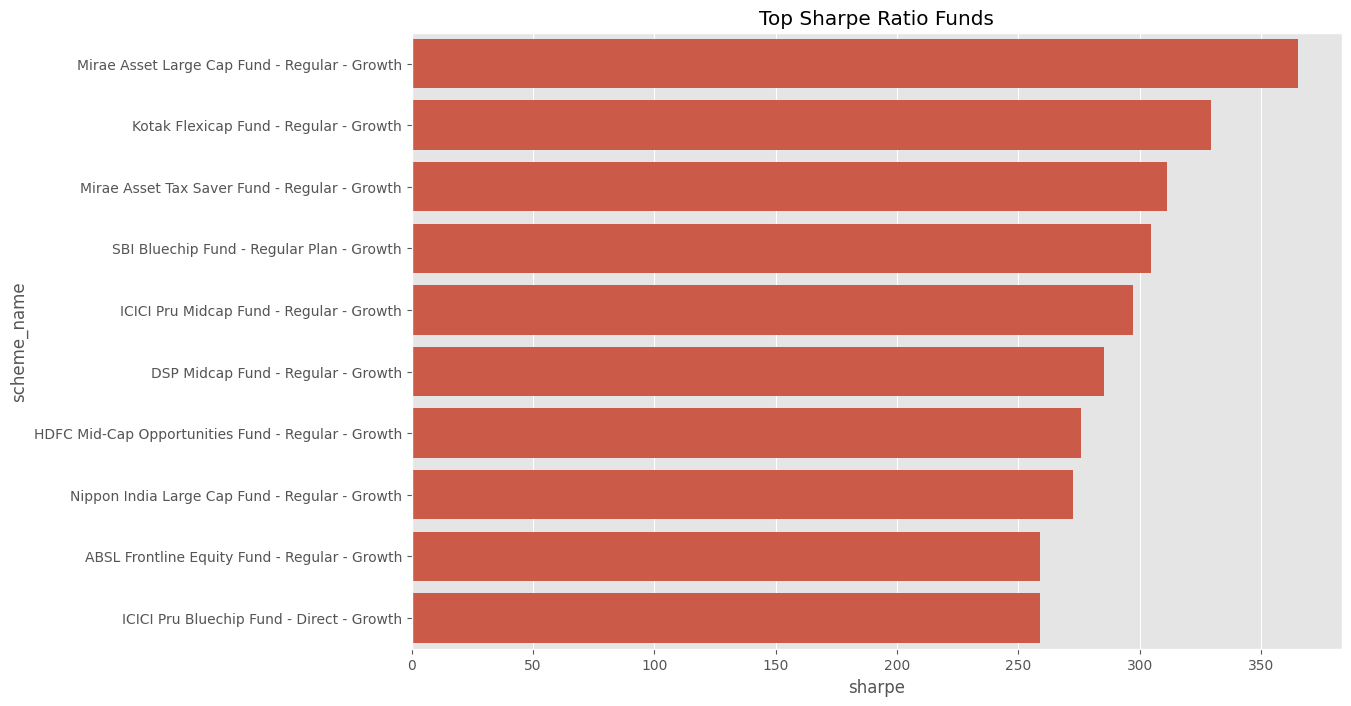

In [9]:
plt.figure(figsize=(12,8))

sns.barplot(

data=sharpe.head(10),

x="sharpe",

y="scheme_name"

)

plt.title("Top Sharpe Ratio Funds")

Sortino Ratio

In [25]:
RF = 0.065      # Annual Risk-Free Rate
TRADING_DAYS = 252

sortino_results = []

for code, group in returns.groupby("amfi_code"):

    # Annualized expected return
    annual_return = group["daily_return"].mean() * TRADING_DAYS

    # Downside returns only
    downside_returns = group.loc[
        group["daily_return"] < 0,
        "daily_return"
    ]

    # Skip if insufficient downside observations
    if len(downside_returns) < 2:
        continue

    downside_std = downside_returns.std()

    # Annualized Sortino Ratio
    sortino = ((annual_return - RF) / downside_std) * np.sqrt(TRADING_DAYS)

    sortino_results.append({
        "amfi_code": code,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
).reset_index(drop=True)

sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

Alpha Beta

In [19]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100 = nifty100.dropna()

merged = pd.merge(
    returns,
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)
print(merged.head())

   amfi_code       date       nav  daily_return  benchmark_return
0     100016 2022-01-04  515.0971     -0.010306         -0.013540
1     100016 2022-01-05  521.7239      0.012865          0.004003
2     100016 2022-01-06  515.7880     -0.011377         -0.002935
3     100016 2022-01-07  515.1639     -0.001210          0.006150
4     100016 2022-01-10  510.7136     -0.008639         -0.008351


OLS Regression

In [20]:
from scipy.stats import linregress

results = []

for code, group in merged.groupby("amfi_code"):

    # Skip funds with too few observations
    if len(group) < 30:
        continue

    regression = linregress(
        group["benchmark_return"],
        group["daily_return"]
    )

    results.append({
        "amfi_code": code,
        "alpha": regression.intercept * 252,
        "beta": regression.slope,
        "r_squared": regression.rvalue ** 2,
        "p_value": regression.pvalue
    })

alpha_beta = pd.DataFrame(results)

alpha_beta = alpha_beta.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

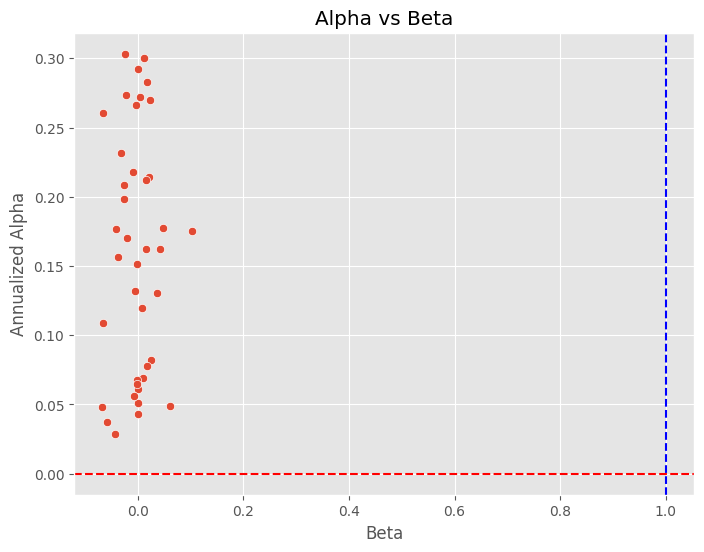

In [22]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=alpha_beta,
    x="beta",
    y="alpha"
)

plt.axhline(0, color="red", linestyle="--")
plt.axvline(1, color="blue", linestyle="--")

plt.title("Alpha vs Beta")
plt.xlabel("Beta")
plt.ylabel("Annualized Alpha")

plt.show()

Maximum Drawdown

In [29]:
max_dd_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    # Running maximum NAV
    group["running_max"] = group["nav"].cummax()

    # Drawdown
    group["drawdown"] = (
        group["nav"] / group["running_max"]
    ) - 1

    max_drawdown = group["drawdown"].min()

    worst_row = group.loc[
        group["drawdown"].idxmin()
    ]
    peak_index = group["nav"].cummax().idxmax()

    trough_index = group["drawdown"].idxmin()

    peak_date = group.loc[peak_index, "date"]

    trough_date = group.loc[trough_index, "date"]

    max_dd_results.append({
        "amfi_code": code,
        "max_drawdown": max_drawdown,
        "worst_date": worst_row["date"],
        "drawdown_start": peak_date,
        "drawdown_end": trough_date
    })

max_dd = pd.DataFrame(max_dd_results)

max_dd = max_dd.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)
max_dd = max_dd.sort_values(
    by="max_drawdown"
).reset_index(drop=True)

max_dd.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)


<Axes: xlabel='max_drawdown', ylabel='scheme_name'>

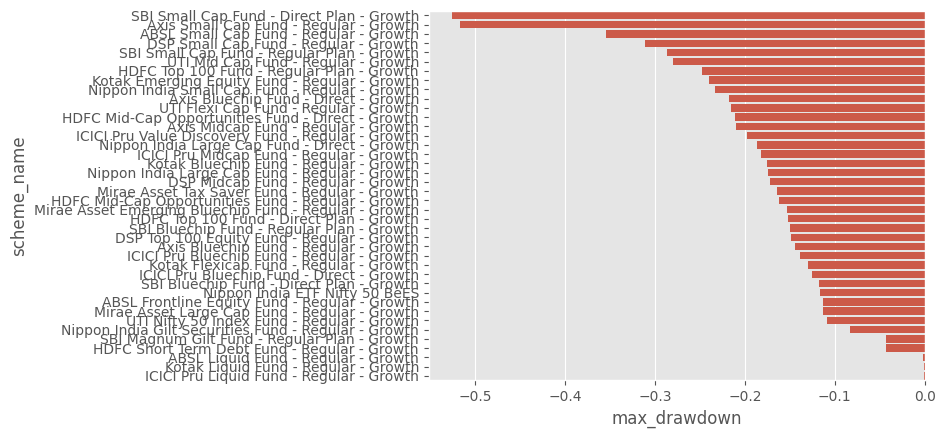

In [30]:
sns.barplot(

data=max_dd.sort_values(

"max_drawdown"

),

x="max_drawdown",

y="scheme_name"

)

Fund Scorecard

In [32]:
score = fund_master[
    ["amfi_code", "scheme_name", "fund_house", "category"]
].copy()

score = score.merge(
    cagr[["amfi_code", "cagr_3yr"]],
    on="amfi_code",
    how="left"
)

score = score.merge(
    sharpe[["amfi_code", "sharpe"]],
    on="amfi_code",
    how="left"
)

score = score.merge(
    alpha_beta[["amfi_code", "alpha"]],
    on="amfi_code",
    how="left"
)

score = score.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ],
    on="amfi_code",
    how="left"
)

score = score.merge(
    max_dd,
    on="amfi_code",
    how="left"
)

score = score.fillna(score.median(numeric_only=True))

def normalize(series, inverse=False):

    if inverse:

        return (
            (series.max() - series)
            /
            (series.max() - series.min())
        ) * 100

    return (
        (series - series.min())
        /
        (series.max() - series.min())
    ) * 100

score["return_score"] = normalize(
    score["cagr_3yr"]
)

score["sharpe_score"] = normalize(
    score["sharpe"]
)

score["alpha_score"] = normalize(
    score["alpha"]
)

score["expense_score"] = normalize(
    score["expense_ratio_pct"],
    inverse=True
)

score["drawdown_score"] = normalize(
    score["max_drawdown"],
    inverse=True
)

score["fund_score"] = (

    0.30 * score["return_score"]

    +

    0.25 * score["sharpe_score"]

    +

    0.20 * score["alpha_score"]

    +

    0.15 * score["expense_score"]

    +

    0.10 * score["drawdown_score"]

)

score["fund_score"] = normalize(
    score["fund_score"]
)

score = score.sort_values(
    "fund_score",
    ascending=False
)

score["rank"] = range(
    1,
    len(score) + 1
)

cols = [
    "cagr_3yr",
    "sharpe",
    "alpha",
    "expense_ratio_pct",
    "max_drawdown",
    "fund_score"
]

score[cols] = score[cols].round(4)

score.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

Benchmark Comparison

In [34]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(["index_name", "date"])

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty50.dropna(inplace=True)

nifty100.dropna(inplace=True)

top5 = score.sort_values(
    "fund_score",
    ascending=False
).head(5)

top5_codes = top5["amfi_code"].tolist()

latest_date = nav["date"].max()

start_date = latest_date - pd.DateOffset(years=3)

nav_3yr = nav[
    nav["date"] >= start_date
].copy()

benchmark_3yr = benchmark[
    benchmark["date"] >= start_date
].copy()

fund_plot = []

for code in top5_codes:

    temp = nav_3yr[
        nav_3yr["amfi_code"] == code
    ].copy()

    temp = temp.sort_values("date")

    temp["normalized"] = (
        temp["nav"]
        / temp["nav"].iloc[0]
    ) * 100

    temp["series"] = fund_master.loc[
        fund_master["amfi_code"] == code,
        "scheme_name"
    ].values[0]

    fund_plot.append(temp)

fund_plot = pd.concat(fund_plot)

nifty50_plot = nifty50[
    nifty50["date"] >= start_date
].copy()

nifty50_plot["normalized"] = (
    nifty50_plot["close_value"]
    / nifty50_plot["close_value"].iloc[0]
) * 100

nifty50_plot["series"] = "NIFTY50"

nifty100_plot = nifty100[
    nifty100["date"] >= start_date
].copy()

nifty100_plot["normalized"] = (
    nifty100_plot["close_value"]
    / nifty100_plot["close_value"].iloc[0]
) * 100

nifty100_plot["series"] = "NIFTY100"

comparison = pd.concat([

    fund_plot[
        ["date", "normalized", "series"]
    ],

    nifty50_plot[
        ["date", "normalized", "series"]
    ],

    nifty100_plot[
        ["date", "normalized", "series"]
    ]

])

import plotly.express as px

fig = px.line(

    comparison,

    x="date",

    y="normalized",

    color="series",

    title="Top 5 Mutual Funds vs Nifty 50 & Nifty 100 (Normalized to 100)"

)

fig.update_layout(

    xaxis_title="Date",

    yaxis_title="Growth Index (Base = 100)",

    height=650

)

fig.show()

fig.write_image(
    "../reports/figures/benchmark_comparison.png",
    width=1600,
    height=900
)

Tracking Error

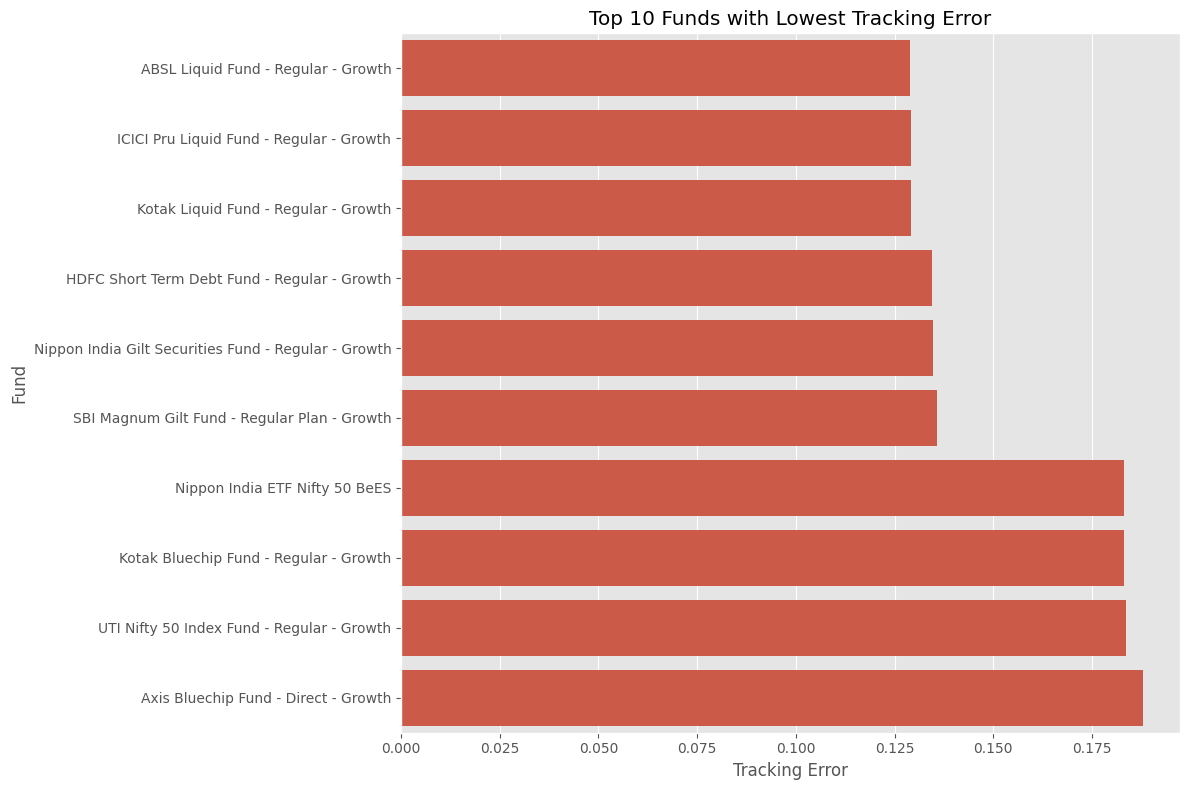

In [35]:
tracking = pd.merge(

    returns,

    nifty100[
        ["date", "benchmark_return"]
    ],

    on="date",

    how="inner"

)

tracking_results = []

for code, group in tracking.groupby("amfi_code"):

    diff = (
        group["daily_return"]
        - group["benchmark_return"]
    )

    te = diff.std() * np.sqrt(252)

    tracking_results.append({

        "amfi_code": code,

        "tracking_error": te

    })

tracking_error = pd.DataFrame(
    tracking_results
)

tracking_error = tracking_error.merge(

    fund_master[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

tracking_error = tracking_error.sort_values(
    "tracking_error"
)

tracking_error.to_csv(
    "../data/processed/tracking_error.csv",
    index=False
)
plt.figure(figsize=(12, 8))

top10 = tracking_error.nsmallest(10, "tracking_error")

sns.barplot(
    data=top10,
    x="tracking_error",
    y="scheme_name"
)

plt.title("Top 10 Funds with Lowest Tracking Error")

plt.xlabel("Tracking Error")

plt.ylabel("Fund")

plt.tight_layout()

plt.savefig(
    "../reports/figures/tracking_error.png",
    dpi=300
)

plt.show()